<a href="https://colab.research.google.com/github/JWasonga/Statistical-Data-Analytics/blob/main/OLS_and_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Cobb-Douglas Y-production dataset.xlsx to Cobb-Douglas Y-production dataset.xlsx


#####This Dataset contains 39 entries with 5 columns: iD, Year, Output, Labor, and Capital. It covers a timespan from 1929 to 1967. All columns are numerical( int64 for id and Year, float64 for Output, Labor, and Capital) and contains no missing value, ensuring a complete and clean dataset for analysis.

###Importing Necessary Libraries

In [2]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings as wr
wr.filterwarnings ('ignore')

###Exploratory Data Analysis

In [3]:
df = pd.read_excel("Cobb-Douglas Y-production dataset.xlsx")
print(df.head())

   id  Year  Output  Labor  Capital
0   1  1929   189.8  173.3     87.8
1   2  1930   172.1  165.4     87.8
2   3  1931   159.1  158.2     84.0
3   4  1932   135.6  141.7     78.3
4   5  1933   132.0  141.6     76.6


In [4]:
df.shape

(39, 5)

The Dataset has 39 rows (observations) and 5 columns (features).

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       39 non-null     int64  
 1   Year     39 non-null     int64  
 2   Output   39 non-null     float64
 3   Labor    39 non-null     float64
 4   Capital  39 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 1.7 KB


#####Each column records 39 observations with 2 interger data types and 3 float data types.No missing values

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,39.0,20.000000,11.401754,1.0,10.50,20.0,29.50,39.0
Year,39.0,1948.000000,11.401754,1929.0,1938.50,1948.0,1957.50,1967.0
Output,39.0,323.635897,144.206001,132.0,189.15,291.1,420.60,631.1
Labor,39.0,217.812821,45.913042,141.6,172.65,228.2,251.55,305.0
Capital,39.0,133.035897,52.224739,76.0,87.40,113.0,172.50,247.9


#####The datset shows a clear trend of increasing Output, Labor, and Capital over the years, as evidenced by the differences between Min and Max values and the spread indicated by standard deviations.



In [7]:
df.columns.tolist()

['id', 'Year', 'Output', 'Labor', 'Capital']

In [8]:
df.isnull().sum()

,0
id,0
Year,0
Output,0
Labor,0
Capital,0


#####No Missing Values in the columns

In [9]:
df.duplicated().sum()

np.int64(0)

#####No Duplicated Values in the dataset

###Univariate Analysis on Output

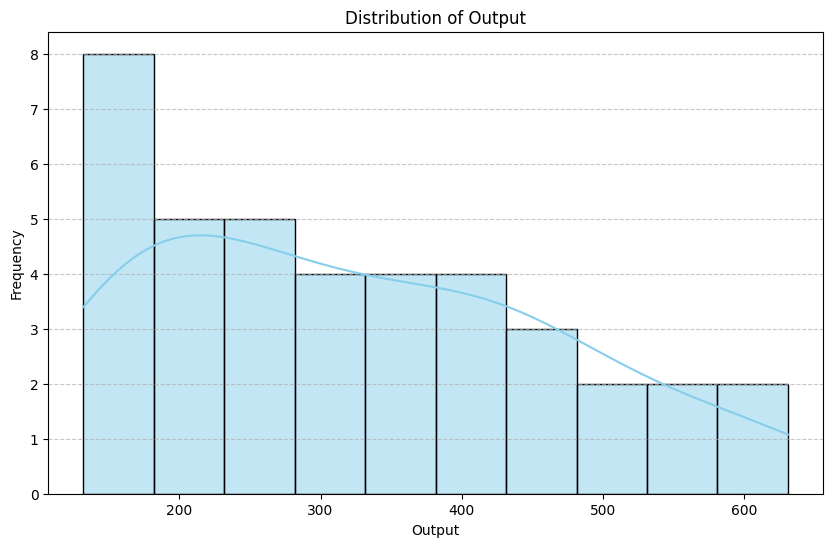

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Output'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Output')
plt.xlabel('Output')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

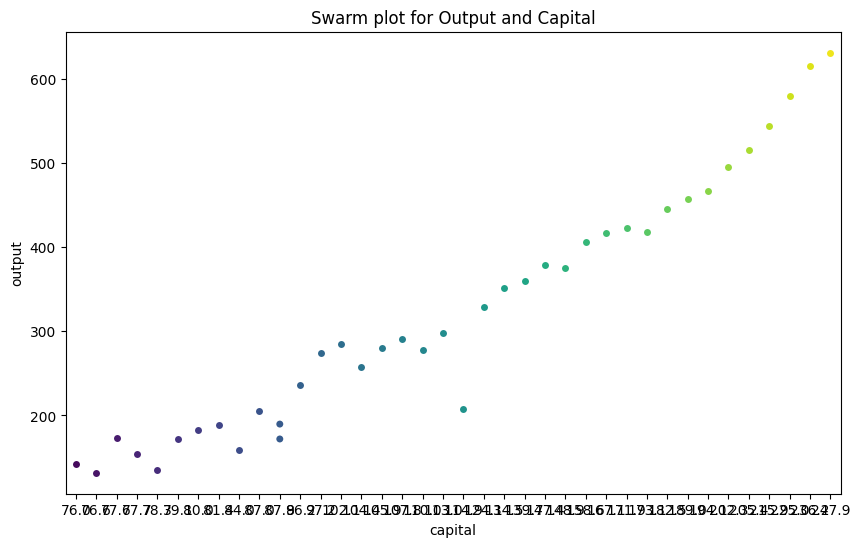

In [ ]:
plt.figure(figsize=(10, 6))
sns.swarmplot(x="Capital", y="Output", data = df, palette = "viridis")
plt.title('Swarm plot for Output and Capital')
plt.xlabel("capital")
plt.ylabel("output")
plt.show()

###Preparing Data for Ols

#####Involves setting up the independent and dependent variables and a constant term (sm.add_constant())

In [ ]:
x = df[['Capital', 'Labor']]
y = df["Output"]
x = sm.add_constant(x)


###Performing OLS Regression

In [ ]:
result = sm.OLS(y,x).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 Output   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     1168.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           1.84e-33
Time:                        17:47:59   Log-Likelihood:                -167.05
No. Observations:                  39   AIC:                             340.1
Df Residuals:                      36   BIC:                             345.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -153.2323     21.945     -6.983      0.0

###Visualizing Regression Line

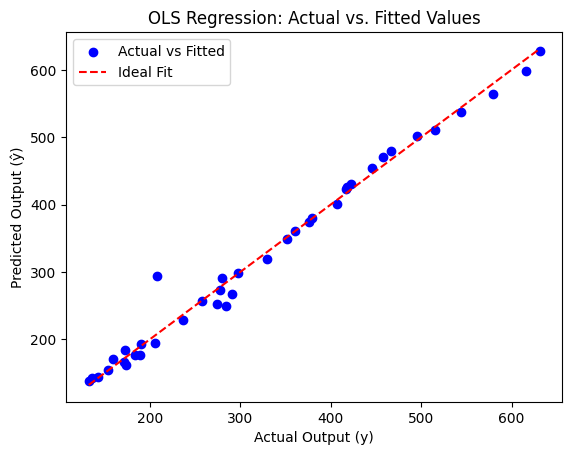

In [ ]:
plt.scatter(y, result.fittedvalues, color='blue', label='Actual vs Fitted')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Ideal Fit') # Line for perfect prediction
plt.xlabel("Actual Output (y)")
plt.ylabel("Predicted Output (ŷ)")
plt.title("OLS Regression: Actual vs. Fitted Values")
plt.legend()
plt.show()

###Hypothesis Testing
#####Normality, Autcorrelation, Multicollinearity, Heteroscedasticity,

####Part one. Heterscedasticity

In [ ]:
import statsmodels.stats.api as sms
names = ['lagrange multiplier statistic', "P-Value", "F-Value", "F P-Value"]
test_result = sms.het_breuschpagan(result.resid, result.model.exog)
print(names, test_result)

['lagrange multiplier statistic', 'P-Value', 'F-Value', 'F P-Value'] (np.float64(2.0761121459945744), np.float64(0.35414244031872066), np.float64(1.0120824430964819), np.float64(0.3735688814275765))


#####The Breusch Pagan Test shows a P-value f 0.354, and since the p-value  is much greater than the common signficance level  of 0.05, we fail to reject the null hypothesis. This suggests there is no statistically significant evidence of heteroscedasticity in the model's residuals

####Part two. Normality

In [17]:
import statsmodels.api as sm

# Ensure x and y are defined (as they are needed for result)
x = df[['Capital', 'Labor']]
y = df["Output"]
x = sm.add_constant(x)

# Ensure result is defined
result = sm.OLS(y,x).fit()

from statsmodels.stats.stattools import jarque_bera
results = jarque_bera(result.resid)
jb_value = results[0]
p_value = results[1]
print(jb_value, p_value)

306.39518492920695 2.9317771236167775e-67


#####The Jarque-Bera test shows a p-value of 2.93e-67. Since, the p-value is significantly smaller than the common significance level of 0.05, we reject the null hypothesis, and suggest that there is statistically significant evidence that the residuals are not normally distributed

#### Correcting for Non-Normality: Log Transformation of Output

To address the non-normality of residuals, we will apply a natural logarithm transformation to the Output variable. This is a common practice that can help normalize the distribution of errors and improve model assumptions.

In [11]:
df['Log_Output'] = np.log(df['Output'])

# Prepare data for the new OLS model with log-transformed Output
x_log = df[['Capital', 'Labor']]
y_log = df['Log_Output']
x_log = sm.add_constant(x_log)

# Re-run OLS regression with Log_Output
result_log = sm.OLS(y_log, x_log).fit()
print(result_log.summary())

                            OLS Regression Results                            
Dep. Variable:             Log_Output   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     587.6
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           3.28e-28
Time:                        08:11:54   Log-Likelihood:                 43.641
No. Observations:                  39   AIC:                            -81.28
Df Residuals:                      36   BIC:                            -76.29
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6682      0.099     37.098      0.0

#### Re-checking Normality with Jarque-Bera Test (after log transformation)

Now, let's re-evaluate the normality of the residuals for the new model (with Log_Output) using the Jarque-Bera test.

In [12]:
from statsmodels.stats.stattools import jarque_bera

results_log_jb = jarque_bera(result_log.resid)
jb_value_log = results_log_jb[0]
p_value_log = results_log_jb[1]
print(f"Jarque-Bera test for Log_Output model residuals: JB={jb_value_log:.3f}, P-value={p_value_log:.3e}")

Jarque-Bera test for Log_Output model residuals: JB=107.658, P-value=4.191e-24


#####Since the p-value 4.191e-24 is still significantly smallertan the common significance level of 0.05, we reject the null hypothesis. Even after the natural logarithmic transformation of output there is still eveidence of non-normality in the residuals. hence the next efficient possible solution, is to use  robust standard errors.

#### Part Three. Autocorrelation

In [ ]:
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# Re-fit the OLS model to ensure 'result' is the correct object
result = sm.OLS(y, x).fit()
dw_statistic = durbin_watson(result.resid)
print(f"Durbin-Watson statistic: {dw_statistic}")

Durbin-Watson statistic: 1.6186750934371494


#####The Durbin-Watson statistic test sis approximately 1.619, this value is close to 2.0 and falls within the generally accepted range (1.5 to 2.5) where is autocorrelation is typically is not considered a significant issue. Therefore, based on the test, there is no strong evidence of significant positive or negative autocorrelation.

#### Part Four. Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Create a DataFrame to store VIF results
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

print(vif_data)

   feature        VIF
0    const  56.354020
1  Capital   8.595598
2    Labor   8.595598


###### The VIF results show a VIF of approximately 8.6 for both 'Capital' and 'Labor'. A VIF value greater than 10 is often considered an indication of multicollinearity. In this case, a VIF of 8.6 suggests no level of multicollinearity between 'Capital' and 'Labor'.
